In [1]:
import pickle 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots
from matplotlib import colors
import json



def load_results(path):
    with open(path, 'rb') as file:
        linkabilityresults = pickle.load(file)
    
    tools = ['Avatars K5', "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", "TVAE"]
    columns = [2,3,5,7,10,20,50]
    ResultasDataset = {}
    for tool, result_as_tool in linkabilityresults.items():
        tool_res = {}
        for i, evaluator in enumerate(result_as_tool):
            # name_feature = feature[0]
            # evaluator = feature[1]
    
            attack_risk = evaluator.risk().value
            naive_risk = evaluator.risk(baseline=True).value
    
            if attack_risk <= naive_risk:
                final_risk = 0
            else:
                final_risk = attack_risk
            tool_res[columns[i]] = final_risk
    
        ResultasDataset[tool] = tool_res
        
    df = pd.DataFrame(ResultasDataset).T
    df.index = tools
    df.columns = columns
    return df


data_path = '../Melanoma/Privacy/SinglingOut/MultiSO/Seed_42/MultiSO_Results.pkl'
results = load_results(data_path)

/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.013786776807497096, baseline = 0.020584165618576494. Analysis results cannot be trusted.
  self._sanity_check()
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.00019199918533829787, baseline = 0.00019199918533829787. Analysis results cannot be trusted.
  self._sanity_check()
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.012087429604727246, baseline = 0.022383474421509276. Analysis results cannot be trusted.
  self._sanity_check()
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confid

In [2]:
cancers = ['ccRCC', 'Melanoma', 'NSCLC']
seed = 42
ResultsLinkability = {}
for cancer in cancers:
    data_path = f'../{cancer}/Privacy/SinglingOut/MultiSO/Seed_{seed}/MultiSO_Results.pkl'

    result_df = load_results(data_path)
    
    ResultsLinkability[cancer] = result_df

/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.00019199918533829787, baseline = 0.0002919607855012302. Analysis results cannot be trusted.
  self._sanity_check()
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.00019199918533829787, baseline = 0.00019199918533829787. Analysis results cannot be trusted.
  self._sanity_check()
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.016285816811570406, baseline = 0.016685663212222136. Analysis results cannot be trusted.
  self._sanity_check()
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/con

In [7]:
ResultsLinkability['ccRCC'].mean(axis = 1)

Avatars K5         0.087861
Avatars K10        0.079593
CTGAN              0.024817
Gaussian Copula    0.044265
Synthpop           0.108480
TVAE               0.047791
dtype: float64

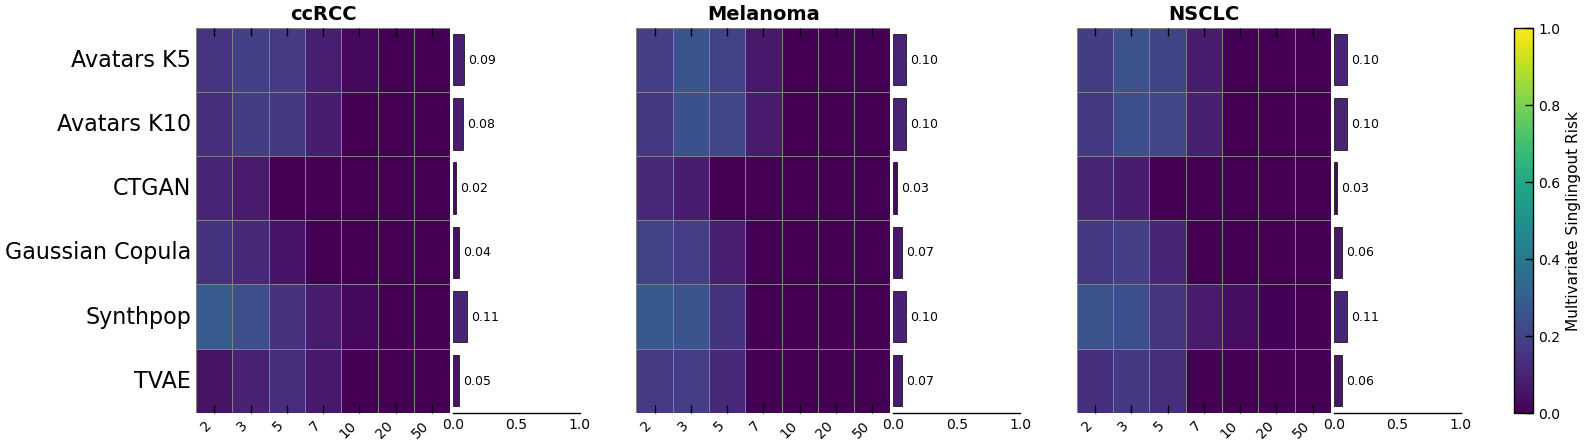

In [4]:
# 1. CẤU HÌNH STYLE
plt.style.use(["science", "nature", "notebook"])
plt.rcParams.update({
    'text.usetex': False,
    'xtick.minor.visible': False,
    'ytick.minor.visible': False
})

# 2. CẤU HÌNH MÀU SẮC TOÀN CỤC
vmin, vmax = 0, 1
cmap = plt.get_cmap("viridis")
norm = colors.Normalize(vmin=vmin, vmax=vmax)
line_params = {'linewidths': 0.5, 'linecolor': 'gray'}

# 3. KHỞI TẠO FIGURE VỚI 9 CỘT
# Cột index 2 và 5 sẽ đóng vai trò là khoảng cách rộng (w=0.2)
fig, axes = plt.subplots(
    1, 9, 
    figsize=(18, 5),
    gridspec_kw={
        'width_ratios': [1, 0.5, 0.2, 1, 0.5, 0.2, 1, 0.5, 0.2],
        'wspace': 0.02 # Khoảng cách hẹp giữa Heatmap và Bar
    }
)

# Các cột bắt đầu của mỗi cụm (Heatmap)
steps = [0, 3, 6] 

for i, step in enumerate(steps):
    dataset = cancers[i]
    ax_heat = axes[step]
    ax_bar = axes[step+1]
    
    # Ẩn các cột đóng vai trò là khoảng trống "giả"
    if step + 2 < len(axes):
        axes[step+2].axis('off')

    data = ResultsLinkability[dataset]
    yticklabels = True if i == 0 else False

    # --- HEATMAP ---
    sns.heatmap(
        data,
        ax=ax_heat,
        cmap=cmap,
        norm=norm,
        cbar=False,
        xticklabels=True,
        yticklabels=yticklabels,
        **line_params
    )
    ax_heat.set_title(dataset, loc='center', fontsize=14, fontweight='bold')
    ax_heat.tick_params(which='major', left=False, right=False)

    # Style cho X-label
    for label in ax_heat.get_xticklabels():
        label.set_rotation(45)
        label.set_fontsize(10)
        label.set_ha('right')

    # --- BAR PLOT (Sửa lỗi mismatch) ---
    means = data.mean(axis=1)
    
    # Tạo y_pos dựa trên số lượng dòng của data để đảm bảo khớp shape
    # 0.5 giúp căn giữa thanh bar vào giữa ô của heatmap
    y_pos = np.arange(len(means)) + 0.5 
    
    bar_colors = cmap(norm(means.values))
    
    bars = ax_bar.barh(
        y_pos,
        means.values,
        color=bar_colors,
        height=0.8,
        edgecolor='black',
        linewidth=0.5
    )

    # Đồng bộ trục Y giữa Bar và Heatmap
    ax_bar.set_ylim(ax_heat.get_ylim())
    ax_bar.set_xlim(vmin, vmax)

    # Hiển thị giá trị số trên đầu thanh bar
    ax_bar.bar_label(
        bars,
        fmt="%.2f",
        padding=3,
        fontsize=9
    )

    # Làm sạch trục Bar
    ax_bar.set_yticks([])
    ax_bar.set_ylabel("")
    ax_bar.spines['left'].set_visible(False)
    ax_bar.spines['top'].set_visible(False)
    ax_bar.spines['right'].set_visible(False)
    ax_bar.tick_params(axis='x', labelsize=10)
    ax_bar.tick_params(which='both', left=False)
    ax_bar.tick_params(which='major', top=False, bottom=False, left=False, right=False)

# 4. SHARED COLORBAR
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Chỉ áp dụng Colorbar cho các trục có chứa dữ liệu thực
valid_axes = [axes[0], axes[1], axes[3], axes[4], axes[6], axes[7]]
cbar = fig.colorbar(
    sm,
    ax=valid_axes,
    orientation='vertical',
    fraction=0.015,
    pad=0.04
)
cbar.set_label("Multivariate Singlingout Risk", fontsize=11)
cbar.ax.tick_params(labelsize=10)

# 5. LƯU VÀ HIỂN THỊ
fig.savefig('SinglingOut_Multi.pdf', dpi=300, bbox_inches='tight')
plt.show()